In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import curve_fit

from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.thorlabs import ThorCam

from slmsuite.hardware.cameraslms import FourierSLM
from slmsuite.holography import toolbox

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


In [2]:
cam = ThorCam(
    rot = "270",
)

TLCameraSDK initializing... success
Looking for cameras... success
ThorCam sn '38459' initializing... success


In [3]:
#cam.set_woi((555, 140, 590, 180))

In [4]:
lut_path = "interpolated_voltage.lut"

slm = Meadowlark(lut_path=lut_path, wav_um=.688, settle_time_s=.3)

Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...

In [5]:
fs = FourierSLM(cam, slm)

In [6]:
cam.set_exposure(6e-3)

0.006005

(<Axes: xlabel='SLM $n$ [pix]', ylabel='SLM $m$ [pix]'>,
 <Axes: xlabel='Camera $i$ [pix]', ylabel='Camera $j$ [pix]'>)

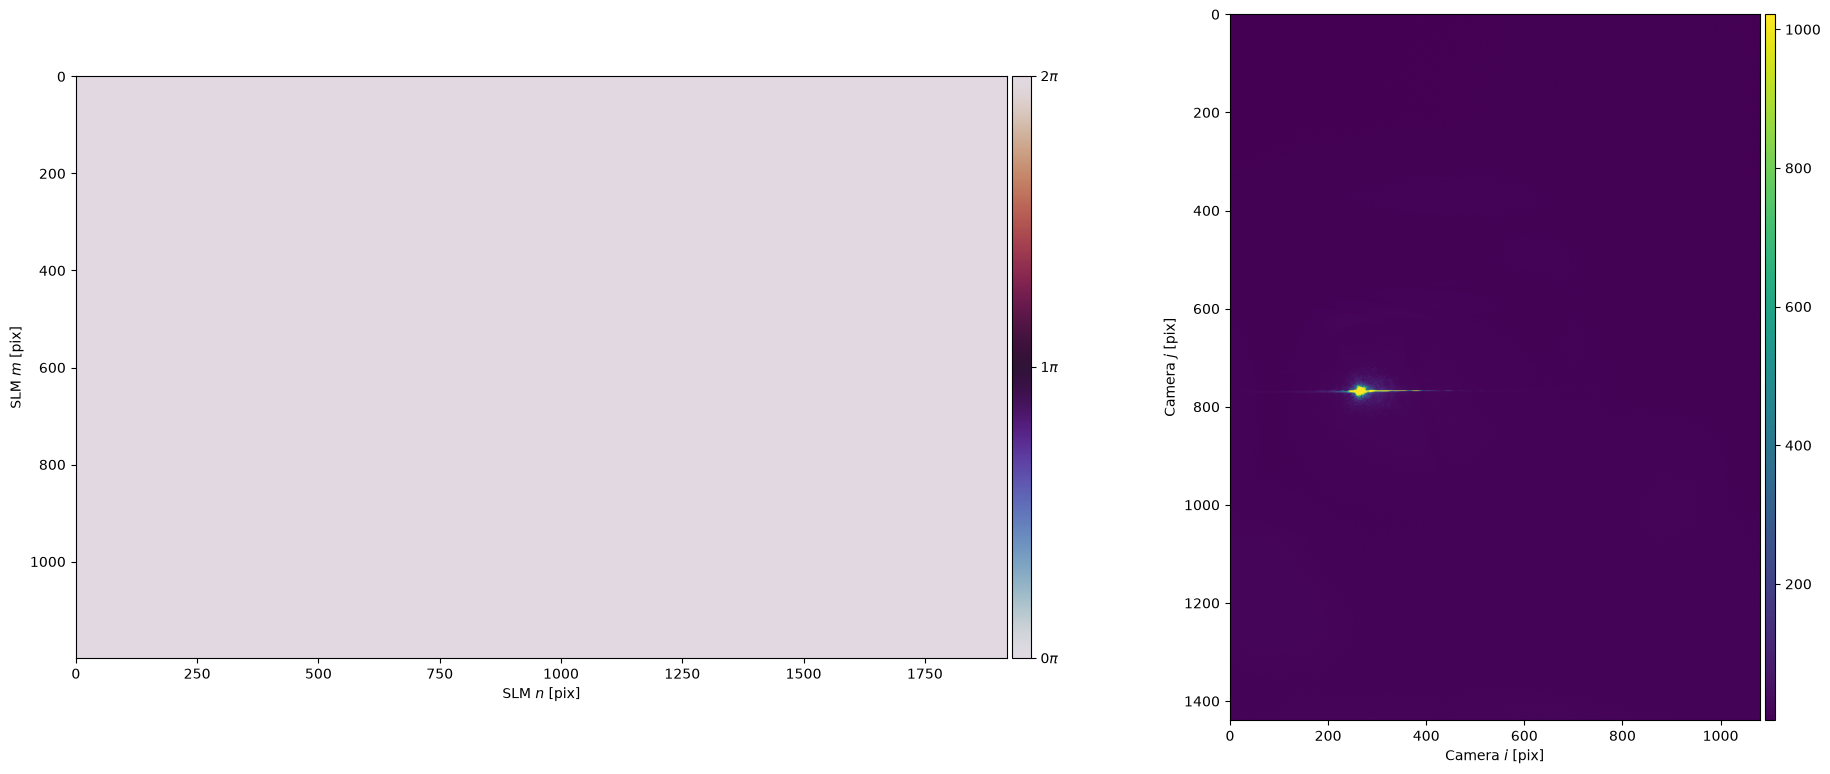

In [7]:
fs.plot()

In [8]:
from slmsuite.holography.toolbox import convert_vector

origin_knm = convert_vector(
    [[0.0], [0.0]],
    from_units="kxy",
    to_units="knm",
    hardware=slm,
    shape=slm.shape,
)

pitch_point_knm = convert_vector(
    [[0.02], [0.00]],
    from_units="kxy",
    to_units="knm",
    hardware=slm,
    shape=slm.shape,
)

pitch_knm = pitch_point_knm - origin_knm;
print(pitch_point_knm, origin_knm, pitch_knm)

[[1406.51162791]
 [ 600.        ]] [[960.]
 [600.]] [[446.51162791]
 [  0.        ]]


In [9]:
slm.shape

(1200, 1920)

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\toolbox\__init__.py:258: UserWarning: CameraSLM must be passed as slm for conversion 'kxy' to 'ij'
  warnings.warn(


  0%|          | 0/10 [00:00<?, ?it/s]

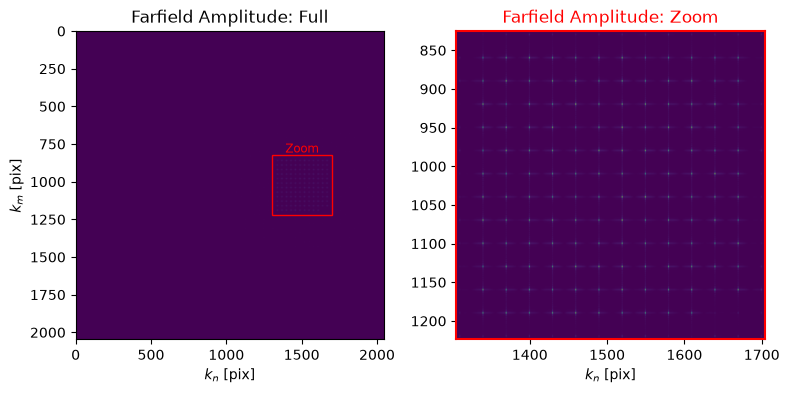

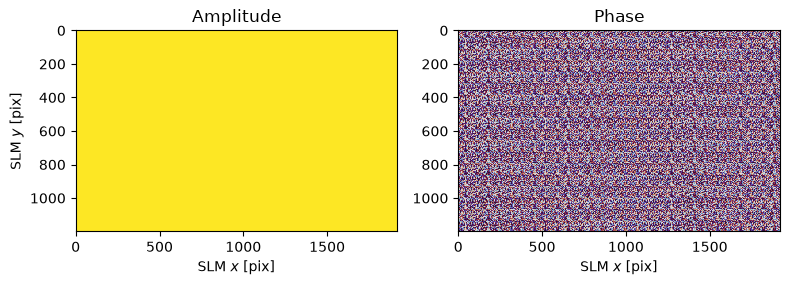

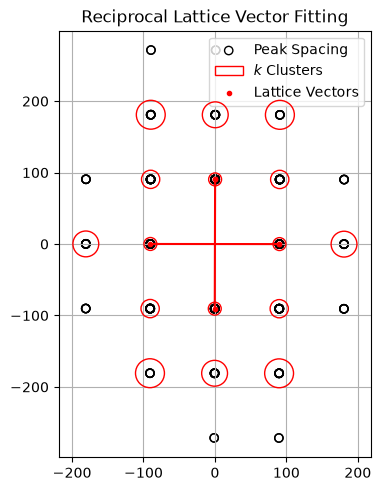

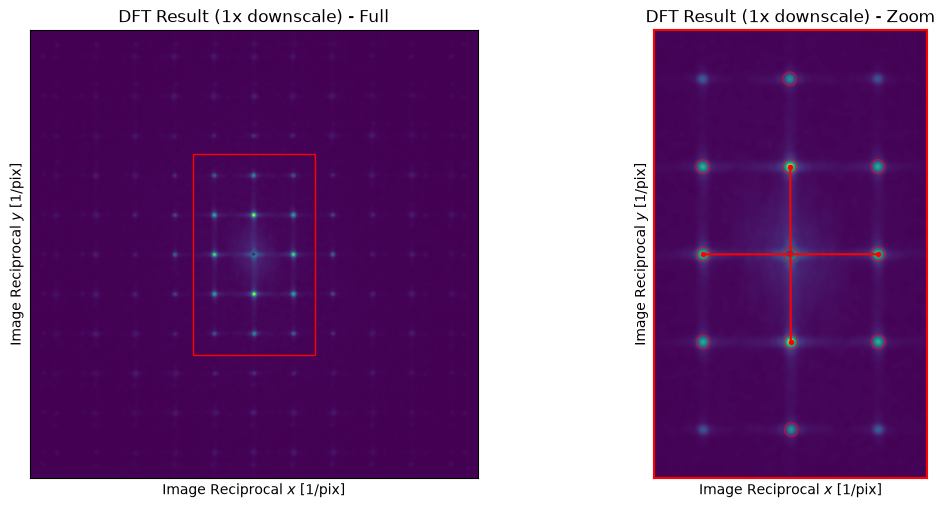

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\analysis\__init__.py:2267: UserWarning: 83.2% of the image's power outside the spot array. This might have caused the array fit to be poor.
  warnings.warn(


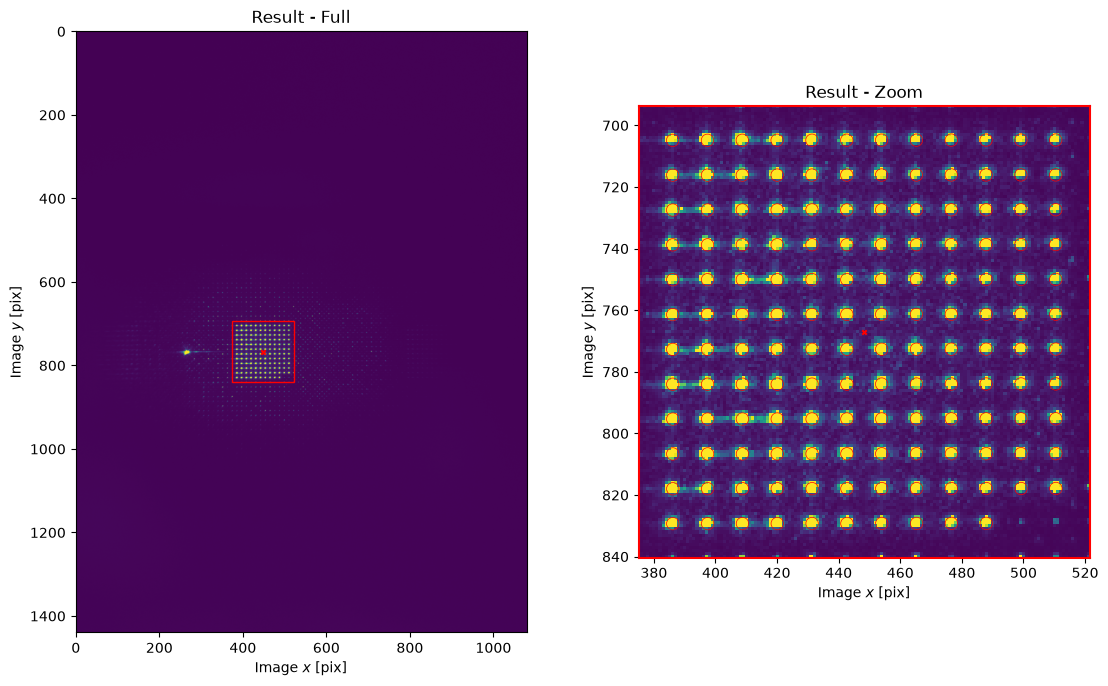

{'M': array([[ 8.97502873e+03,  3.35926123e+00],
        [-7.21300140e+00,  8.97966979e+03]]),
 'b': array([[448.30591606],
        [767.01588919]]),
 'a': array([[ 2.01562500e-02],
        [-3.96508223e-19]]),
 '__version__': '0.4.1',
 '__time__': '2026-09-09 17:58:17.370115',
 '__timestamp__': 1788973097.370115,
 '__meta__': {'__class__': '<slmsuite.hardware.cameraslms.FourierSLM object at 0x000001C59EE83260>',
  'name': '38459-Meadowlark HDMI',
  'cam': {'__class__': '<slmsuite.hardware.cameras.thorlabs.ThorCam object at 0x000001C59EAAC8C0>',
   'name': '38459',
   'shape': (1440, 1080),
   'bitdepth': 10,
   'bitresolution': 1024,
   'pitch_um': array([3.45, 3.45]),
   'exposure_s': 0.006005,
   'exposure_bounds_s': None,
   'averaging': None,
   'hdr': None,
   'woi': (0, 1440, 0, 1080),
   'default_shape': (1440, 1080)},
  'slm': {'__class__': '<slmsuite.hardware.slms.meadowlark.Meadowlark object at 0x000001C59E876810>',
   'name': 'Meadowlark HDMI',
   'shape': (1200, 1920),
   

In [10]:
fs.fourier_calibrate(
    array_center=(480,0),#(480,0), #(500,20)
    array_shape=12,                 # Size of the calibration grid (Nx, Ny) [#]
    array_pitch=30, #16                 # Pitch of the calibration grid (x, y) [knm]
    plot=2,
)

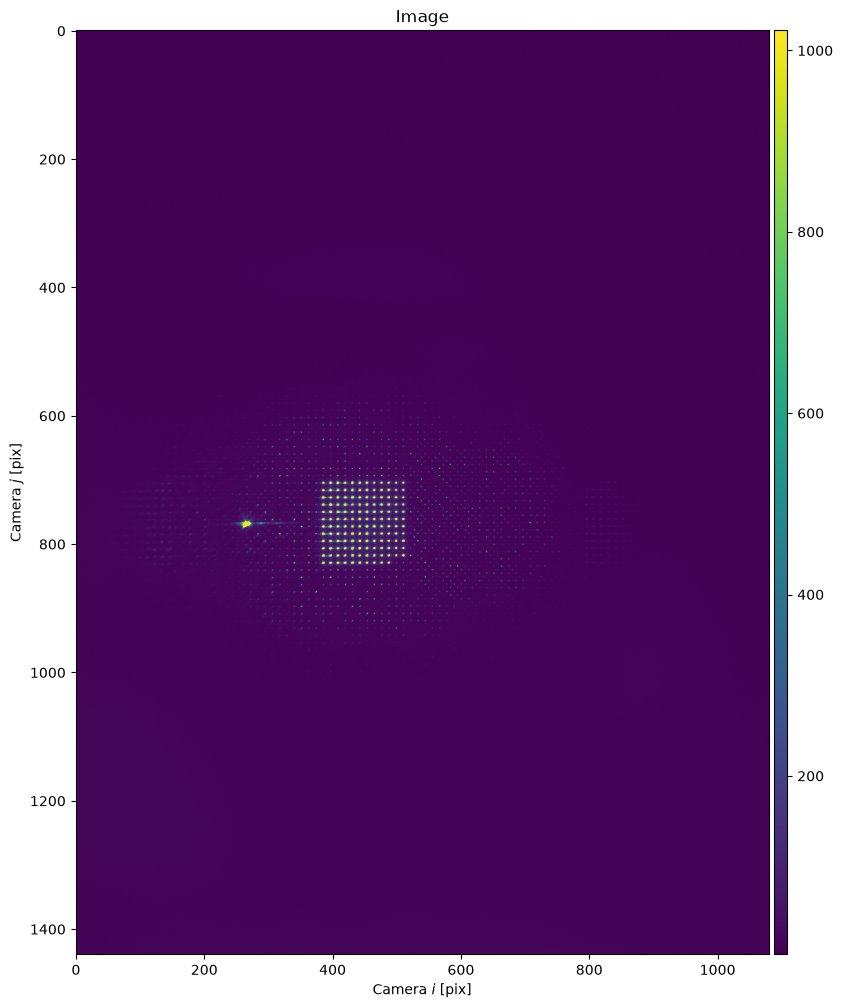

In [11]:
#fs.cam.set_woi((410, 400, 350, 400))

img = fs.cam.get_image()                                        # Grab image.

plt.figure(figsize=(12,12))
fs.cam.plot(img);

In [12]:
fs.save_calibration("fourier")

'c:\\Users\\Xander\\Documents\\Code\\slm\\38459-Meadowlark HDMI-fourier-calibration_00000.h5'

In [13]:
vector = fs.ijcam_to_kxyslm((840, 600))
print(vector)

[[ 0.06380585]
 [-0.01856427]]


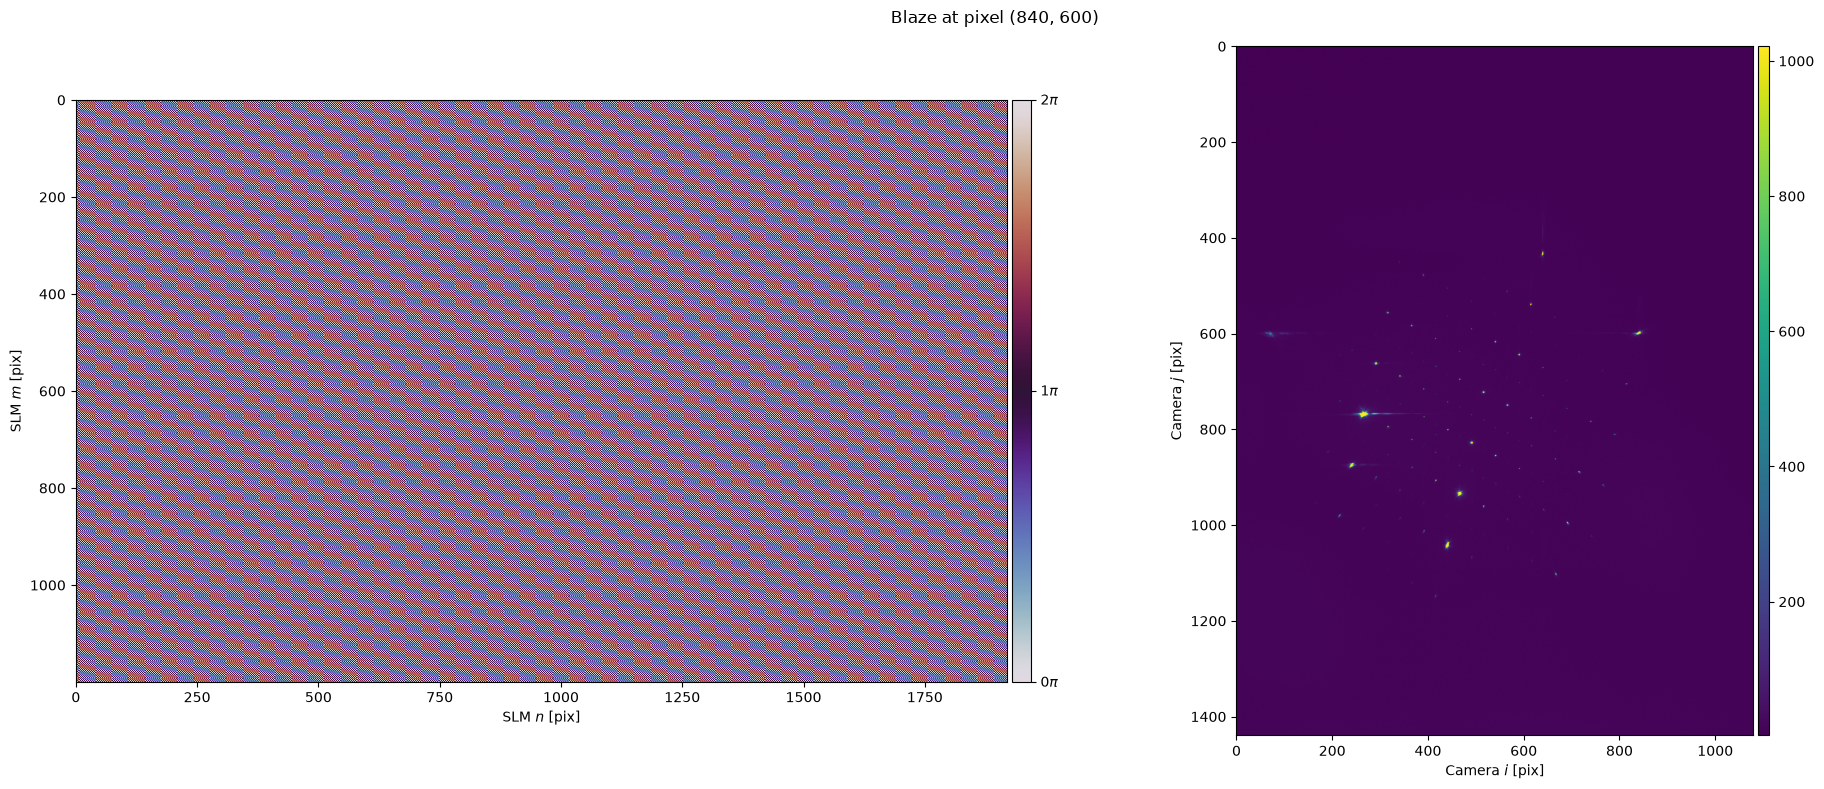

In [14]:
blaze_phase = toolbox.phase.blaze(grid=slm, vector=vector)

fs.plot(blaze_phase, title="Blaze at pixel (840, 600)")

img = cam.get_image()